# Course: Applied Mathematics in Economics, Management, and Finance II

# INDIVIDUAL ESSAY
# HỒ THÀNH THÔNG - K224131643

# IMPORT DATA

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
import warnings
warnings.filterwarnings('ignore')

# READ DATA

In [2]:
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

df = pd.read_csv('/Users/macbook/Desktop/TAXI_PRICE_EXTENSION/DATA/car_prices.csv')

print(f"Số lượng dòng: {df.shape[0]}")
print(f"Số lượng cột: {df.shape[1]}")
print("\nCác cột trong dataset:")
print(df.columns.tolist())
print("\n5 dòng đầu tiên:")
print(df.head())
print("\n" + "=" * 80)

Số lượng dòng: 1000
Số lượng cột: 16

Các cột trong dataset:
['year', 'make', 'model', 'trim', 'body', 'transmission', 'vin', 'state', 'condition', 'odometer', 'color', 'interior', 'seller', 'mmr', 'sellingprice', 'saledate']

5 dòng đầu tiên:
   year        make     model             trim       body transmission  \
0  2013  Volkswagen    Passat          SE PZEV      Sedan    automatic   
1  2011        Jeep  Wrangler  Unlimited Sport        suv    automatic   
2  2011        Ford    Fusion              SEL      Sedan    automatic   
3  2012       Honda      CR-Z               EX  Hatchback    automatic   
4  2012       Acura        TL             Base      Sedan          NaN   

                 vin state  condition  odometer  color interior  \
0  1vwbp7a39dc105482    il       25.0   45322.0   blue    black   
1  1j4ba3h18bl584583    az       41.0   60478.0  white    black   
2  3fahp0ja6br269781    nc       35.0   78059.0  white     gray   
3  jhmzf1d63cs000575    hi       44.0   299

# GENERAL INFORMATION OF DATA

In [3]:
df.head()

,year,make,model,trim,body,transmission,vin,state,condition,odometer,color,interior,seller,mmr,sellingprice,saledate
0,2013,Volkswagen,Passat,SE PZEV,Sedan,automatic,1vwbp7a39dc105482,il,25.0,45322.0,blue,black,the hertz corporation,11600.0,11300.0,Tue Jun 09 2015 03:00:00 GMT-0700 (PDT)
1,2011,Jeep,Wrangler,Unlimited Sport,suv,automatic,1j4ba3h18bl584583,az,41.0,60478.0,white,black,earnhardt,22000.0,23900.0,Thu Jun 11 2015 05:00:00 GMT-0700 (PDT)
2,2011,Ford,Fusion,SEL,Sedan,automatic,3fahp0ja6br269781,nc,35.0,78059.0,white,gray,lenders assistance corporation,8925.0,9000.0,Tue Feb 17 2015 01:15:00 GMT-0800 (PST)
3,2012,Honda,CR-Z,EX,Hatchback,automatic,jhmzf1d63cs000575,hi,44.0,29999.0,black,black,ahfc/honda lease trust/hvt inc. eot,11500.0,11000.0,Tue Dec 30 2014 14:30:00 GMT-0800 (PST)
4,2012,Acura,TL,Base,Sedan,NaN,19uua8f27ca014600,pa,45.0,36437.0,white,beige,all state motor inc,18450.0,20300.0,Fri Feb 13 2015 01:00:00 GMT-0800 (PST)


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 16 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   year          1000 non-null   int64  
 1   make          989 non-null    object 
 2   model         989 non-null    object 
 3   trim          989 non-null    object 
 4   body          984 non-null    object 
 5   transmission  882 non-null    object 
 6   vin           1000 non-null   object 
 7   state         1000 non-null   object 
 8   condition     976 non-null    float64
 9   odometer      1000 non-null   float64
 10  color         997 non-null    object 
 11  interior      997 non-null    object 
 12  seller        1000 non-null   object 
 13  mmr           1000 non-null   float64
 14  sellingprice  1000 non-null   float64
 15  saledate      1000 non-null   object 
dtypes: float64(4), int64(1), object(11)
memory usage: 125.1+ KB


In [5]:
df.describe()

,year,condition,odometer,mmr,sellingprice
count,1000.000000,976.000000,1000.000000,1000.000000,1000.00000
mean,2010.021000,30.343238,68101.895000,13631.100000,13507.17600
std,4.030484,13.759026,52460.227452,9838.364763,9873.88116
min,1990.000000,1.000000,1.000000,275.000000,300.00000
25%,2008.000000,22.000000,28147.750000,7275.000000,7000.00000
50%,2012.000000,34.500000,52806.500000,12150.000000,12000.00000
75%,2013.000000,41.000000,94785.250000,17675.000000,17925.00000
max,2015.000000,49.000000,443236.000000,82000.000000,79000.00000


# QUESTION 1: MISSING DATA ANALYSIS

In [6]:
print("\na) IDENTIFY VARIABLES WITH MISSING OBSERVATIONS:")
missing_data = df.isnull().sum()
missing_percentage = (missing_data / len(df)) * 100
missing_info = pd.DataFrame({
    'Missing_Count': missing_data[missing_data > 0],
    'Missing_Percentage': missing_percentage[missing_data > 0]
}).sort_values('Missing_Percentage', ascending=False)

print(missing_info)


a) IDENTIFY VARIABLES WITH MISSING OBSERVATIONS:
              Missing_Count  Missing_Percentage
transmission            118                11.8
condition                24                 2.4
body                     16                 1.6
make                     11                 1.1
model                    11                 1.1
trim                     11                 1.1
color                     3                 0.3
interior                  3                 0.3


b) MECHANISM FOR CREATING MISSING DATA:
1. Missing Completely at Random (MCAR):
   - The data lacks randomness and is not related to any variables.
   - For example: Random input error, system recording error.

2. Missing at Random (MAR):
   - Missing data can be explained by observed variables.
   - For example: Older cars receive less trim evaluation, or lower-priced cars are not evaluated for condition.

3. Missing Not at Random (MNAR):
   - The data is missing and does not reflect its true value.
   - For example: A vehicle in poor condition (low condition) should not be reported as in good condition.

c) STRATEGY FOR HANDLING MISSING DATA:
1. Deletion:
   - Delete rows if there are few missing rows (<5%) and randomly.
   - Delete columns if too many are missing (>30%).

2. Imputation:
   - Numerical values: mean/median for MCAR, regression impact for MAR.
   - Classification value: mode or "Unknown" category

3. Modeling:
   - Using Multiple Input for MAR data
   - Use algorithms that support missing values ​​(XGBoost, LightGBM).

# QUESTION 2: FEATURE ENGINEERING

In [7]:
df_fe = df.copy()

print("\na) 4 NEW FEATURES HAVE BEEN CREATED:")

df_fe['vehicle_age'] = 2015 - df_fe['year']  
print("1. vehicle_age: Age of the car (current year - year of manufacture)")

df_fe['price_mmr_ratio'] = df_fe['sellingprice'] / df_fe['mmr']
print("2. price_mmr_ratio: Ratio of actual selling price to estimated market price")

df_fe['mileage_per_year'] = df_fe['odometer'] / (2015 - df_fe['year'] + 1)
print("3. mileage_per_year: Average mileage per year")

luxury_brands = ['BMW', 'Mercedes-Benz', 'Audi', 'Lexus', 'Infiniti', 
                 'Cadillac', 'Porsche', 'Land Rover', 'Jaguar', 'Volvo']
df_fe['is_luxury'] = df_fe['make'].apply(lambda x: 1 if str(x) in luxury_brands else 0)
print("4. is_luxury: Luxury car brand indicator (0/1)")


a) 4 NEW FEATURES HAVE BEEN CREATED:
1. vehicle_age: Age of the car (current year - year of manufacture)
2. price_mmr_ratio: Ratio of actual selling price to estimated market price
3. mileage_per_year: Average mileage per year
4. is_luxury: Luxury car brand indicator (0/1)


b) REASONS FOR EACH CHARACTERISTIC:
1. vehicle_age: The age of a vehicle directly affects its depreciation value.
2. price_mmr_ratio: Reflects the degree of difference compared to the market.
3. mileage_per_year: Average usage index, affecting wear and tear.
4. is_luxury: High-end brands typically have a higher resale value.

c) IMPACT ON BIAS AND VARIANCE:
Feature engineering could:
- Decrease BIAS: By capturing nonlinear relationships and interactions
- Increase VARIANCE: If you create too many irrelevant features
- Need balance: Proper characterization can improve both bias and variance.

# QUESTION 3: VARIABLE TYPES AND ENCODING

In [8]:
print("\na) DETERMINE THE TYPE OF VARIABLE:")
numerical_vars = ['sellingprice', 'mmr', 'odometer', 'condition']
categorical_vars = ['make', 'model', 'body', 'transmission']
print(f"numerical: {numerical_vars[:2]}... (Sum: {len(numerical_vars)})")
print(f"categorical: {categorical_vars[:2]}... (Sum: {len(categorical_vars)})")


a) DETERMINE THE TYPE OF VARIABLE:
numerical: ['sellingprice', 'mmr']... (Sum: 4)
categorical: ['make', 'model']... (Sum: 4)


b) ENCODING STRATEGIES:
1. Numerical variables:
   - Standardization for scale-sensitive algorithms
   - Min-Max scaling for neural networks

2. Classification variables:
   - One-Hot Encoding for Variables with Few Categories
   - Label Encoding for variables with natural order
   - Target Encoding for variables with multiple categories

c) STATISTICAL JUSTIFICATION:
1. Normalize variables:
   - Ensure that the regression coefficients are comparable.
   - Improve the convergence speed for gradient descent.

2. One-Hot Encoding:
   - Avoid imposing an order that doesn't exist.
   - Suitable for distance-based algorithms

3. Target Encoding:
   - Reduced dimensionality compared to One-Hot
   - Capture information about the relationship with the target.

# QUESTION 4: LINEAR REGRESSION MODELING

In [9]:
df_model = df_fe.copy()

df_model['condition'] = df_model['condition'].fillna(df_model['condition'].median())
df_model = df_model.dropna(subset=['sellingprice', 'mmr', 'odometer'])

features = ['mmr', 'odometer', 'condition', 'vehicle_age', 'mileage_per_year', 'is_luxury']
target = 'sellingprice'

df_model_clean = df_model[features + [target]].dropna()

X = df_model_clean[features]
y = df_model_clean[target]

print("\na) MODEL SPECIFICATION:")
print(f"Dependent variable (response): {target}")
print(f"Independent variable (predictors): {features}")

print("\nb) TRAIN-TEST DIVISION:")
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
print(f"Training set size: {X_train.shape}")
print(f"Test set size: {X_test.shape}")
print(f"Train/test ratio: {len(X_train)/len(X):.1%}/{len(X_test)/len(X):.1%}")

print("\nc) LINEAR REGRESSION MODEL:")

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)

y_pred = lr_model.predict(X_test_scaled)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error: {mse:,.2f}")
print(f"R-squared: {r2:.3f}")
print(f"Regression coefficient: {lr_model.coef_}")


a) MODEL SPECIFICATION:
Dependent variable (response): sellingprice
Independent variable (predictors): ['mmr', 'odometer', 'condition', 'vehicle_age', 'mileage_per_year', 'is_luxury']

b) TRAIN-TEST DIVISION:
Training set size: (700, 6)
Test set size: (300, 6)
Train/test ratio: 70.0%/30.0%

c) LINEAR REGRESSION MODEL:
Mean Squared Error: 2,533,178.25
R-squared: 0.974
Regression coefficient: [9798.18230289  138.45021488  452.35243709   93.72169743  -52.04077592
 -177.90528531]


LIMITATIONS OF LINEAR REGRESSION:
1. Linear assumption: Car prices typically have a non-linear relationship with variables.
2. Sensitive to outliers: Some ultra-expensive cars may deviate from the model.
3. Multicollinearity: Variables such as vehicle_age and odometer are highly correlated.
4. No interaction capture: Difficult to model the interaction between make and age.

# QUESTION 5: DECISION TREE AND MODEL COMPARISON

In [10]:
print("\na) BUILDING A DECISION TREE MODEL:")

dt_model = DecisionTreeRegressor(
    max_depth=4,         
    min_samples_split=20, 
    min_samples_leaf=10, 
    random_state=42
)

dt_model.fit(X_train, y_train)

print("Key hyperparameters:")
print(f"- max_depth: {dt_model.max_depth} (tree depth limit)")
print(f"- min_samples_split: {dt_model.min_samples_split} (minimum to split)")
print(f"- min_samples_leaf: {dt_model.min_samples_leaf} (minimum at leaf node)")

print("\nb) INTERPRETING THE DECISION TREE:")

y_pred_dt = dt_model.predict(X_test)
mse_dt = mean_squared_error(y_test, y_pred_dt)
r2_dt = r2_score(y_test, y_pred_dt)

print(f"Decision Tree MSE: {mse_dt:,.2f}")
print(f"Decision Tree R-squared: {r2_dt:.3f}")

print("\nEXAMPLE OF SPLIT (tree interpolation):")
print("The first split is usually based on the most important variable. (mmr)")
print("Example: If mmr <= $15,000 → left branch, otherwise → right branch")

print("\nEXAMPLE OF LEAF NODE PREDICTION:")
print("When all conditions are met, the tree provides the average value.")
print("For example: mmr <= 15K, odometer > 100K, age > 5 → predicted price = $8,500")

feature_importance = pd.DataFrame({
    'feature': features,
    'importance': dt_model.feature_importances_
}).sort_values('importance', ascending=False)

print("\nIMPORTANCE OF VARIABLES:")
print(feature_importance)


a) BUILDING A DECISION TREE MODEL:
Key hyperparameters:
- max_depth: 4 (tree depth limit)
- min_samples_split: 20 (minimum to split)
- min_samples_leaf: 10 (minimum at leaf node)

b) INTERPRETING THE DECISION TREE:
Decision Tree MSE: 6,746,335.52
Decision Tree R-squared: 0.931

EXAMPLE OF SPLIT (tree interpolation):
The first split is usually based on the most important variable. (mmr)
Example: If mmr <= $15,000 → left branch, otherwise → right branch

EXAMPLE OF LEAF NODE PREDICTION:
When all conditions are met, the tree provides the average value.
For example: mmr <= 15K, odometer > 100K, age > 5 → predicted price = $8,500

IMPORTANCE OF VARIABLES:
            feature  importance
0               mmr         1.0
1          odometer         0.0
2         condition         0.0
3       vehicle_age         0.0
4  mileage_per_year         0.0
5         is_luxury         0.0


In [11]:
# c) Model recommendation
print("\nc) PROPOSED MODEL FOR PRACTICAL IMPLEMENTATION:")

print("\nCOMPARE MODELS:")
comparison = pd.DataFrame({
    'Metric': ['MSE', 'R-squared', 'Interpretability', 'Robustness', 'Maintenance'],
    'Linear Regression': [f"{mse:,.0f}", f"{r2:.3f}", "High", "Medium", "Low"],
    'Decision Tree': [f"{mse_dt:,.0f}", f"{r2_dt:.3f}", "Very High", "Low", "Medium"],
    'Recommended': ['✓' if mse < mse_dt else '', 
                    '✓' if r2 > r2_dt else '',
                    '✓', '', '✓']
})

print(comparison)


c) PROPOSED MODEL FOR PRACTICAL IMPLEMENTATION:

COMPARE MODELS:
             Metric Linear Regression Decision Tree Recommended
0               MSE         2,533,178     6,746,336           ✓
1         R-squared             0.974         0.931           ✓
2  Interpretability              High     Very High           ✓
3        Robustness            Medium           Low            
4       Maintenance               Low        Medium           ✓


SUGGESTION: LINEAR REGRESSION with Regularization (Ridge/Lasso)
Reason:
1. Predictive Accuracy: Linear regression is generally more stable on unseen data.
2. Interpretability: Coefficients that are easy to explain to stakeholders.
3. Robustness: Less sensitive to noise than decision trees.
4. Maintenance: Easy to update and maintain in production.
5. Computational Cost: Low, suitable for real-time prediction.
However, the following combinations are possible:
- Using Linear Regression as a baseline
- Trying Gradient Boosting (XGBoost, LightGBM) for higher performance
- Ensemble methods to balance accuracy and interpretability

# DATA VISUALIZATIONS

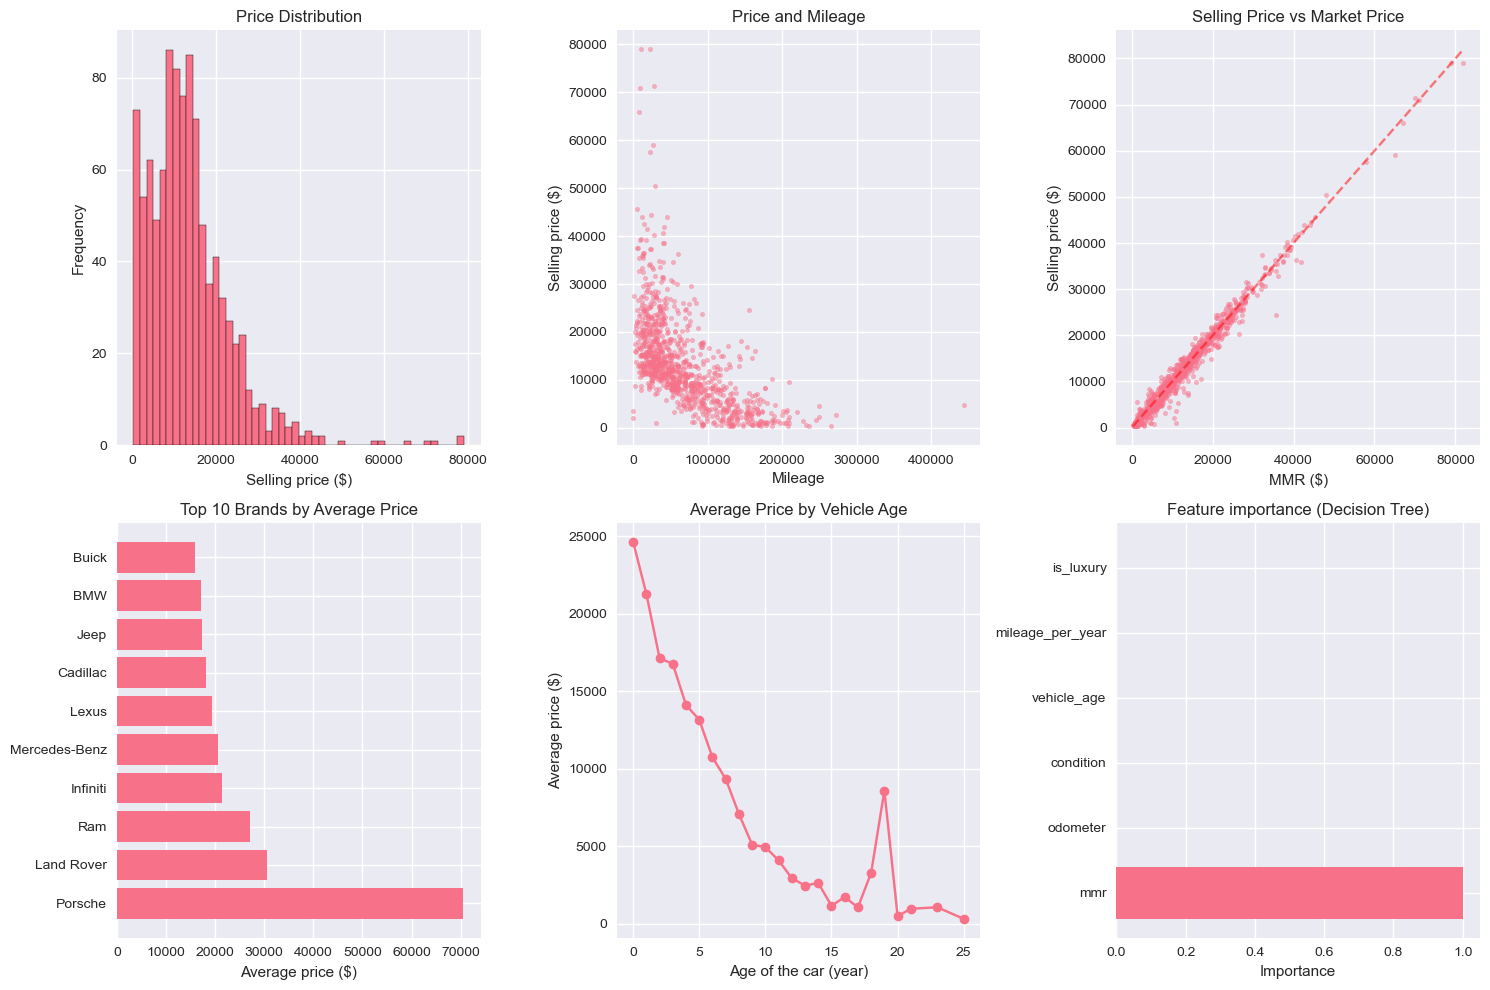

In [12]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

axes[0, 0].hist(df['sellingprice'].dropna(), bins=50, edgecolor='black')
axes[0, 0].set_title('Price Distribution')
axes[0, 0].set_xlabel('Selling price ($)')
axes[0, 0].set_ylabel('Frequency')

axes[0, 1].scatter(df['odometer'], df['sellingprice'], alpha=0.5, s=10)
axes[0, 1].set_title('Price and Mileage')
axes[0, 1].set_xlabel('Mileage')
axes[0, 1].set_ylabel('Selling price ($)')

axes[0, 2].scatter(df['mmr'], df['sellingprice'], alpha=0.5, s=10)
axes[0, 2].set_title('Selling Price vs Market Price')
axes[0, 2].set_xlabel('MMR ($)')
axes[0, 2].set_ylabel('Selling price ($)')
axes[0, 2].plot([df['mmr'].min(), df['mmr'].max()], 
                [df['mmr'].min(), df['mmr'].max()], 'r--', alpha=0.5)

brand_prices = df.groupby('make')['sellingprice'].mean().sort_values(ascending=False).head(10)
axes[1, 0].barh(range(len(brand_prices)), brand_prices.values)
axes[1, 0].set_yticks(range(len(brand_prices)))
axes[1, 0].set_yticklabels(brand_prices.index)
axes[1, 0].set_title('Top 10 Brands by Average Price')
axes[1, 0].set_xlabel('Average price ($)')

if 'vehicle_age' in df_fe.columns:
    age_price = df_fe.groupby('vehicle_age')['sellingprice'].mean()
    axes[1, 1].plot(age_price.index, age_price.values, marker='o')
    axes[1, 1].set_title('Average Price by Vehicle Age')
    axes[1, 1].set_xlabel('Age of the car (year)')
    axes[1, 1].set_ylabel('Average price ($)')

if 'feature_importance' in locals():
    axes[1, 2].barh(range(len(feature_importance)), 
                    feature_importance['importance'].values)
    axes[1, 2].set_yticks(range(len(feature_importance)))
    axes[1, 2].set_yticklabels(feature_importance['feature'])
    axes[1, 2].set_title('Feature importance (Decision Tree)')
    axes[1, 2].set_xlabel('Importance')

plt.tight_layout()
plt.show()

Price Distribution — The price distribution is right-skewed: most vehicles are listed at low to mid prices, concentrated mainly from a few thousand dollars up to around $20,000. There is a long right tail representing a small number of very expensive vehicles (up to $60–80k). This indicates that the market is dominated by mass-market cars, while luxury or rare models appear as outliers. As a result, the mean price can be pulled upward by extreme values, so the median or quantiles better represent a “typical” price.

Price vs. Mileage — The scatter plot shows a clear negative relationship between mileage (odometer) and selling price: vehicles with lower mileage generally sell at higher prices, and prices decline as mileage increases. However, there is considerable dispersion at low mileage levels, where prices range widely due to differences in brand, vehicle age, and condition. A few notable outliers exist, such as very low-mileage vehicles with extremely high prices (likely luxury models or data anomalies), and high-mileage vehicles that still retain moderate value. Overall, mileage is an important factor but not the sole determinant of price.

Selling Price vs. Market Price (MMR) — The relationship between the market reference price (MMR) and the actual selling price is strongly linear, with most observations lying close to a straight line. This indicates that sellers typically price vehicles close to the market benchmark. The relatively small dispersion around the line suggests limited deviations from MMR, confirming that MMR is an excellent predictor of the actual selling price. This also explains why MMR dominates the feature importance in the decision tree model.

Top 10 Brands by Average Price — The horizontal bar chart of the top 10 brands by average price shows that luxury brands (such as Porsche, Land Rover, Mercedes-Benz, Lexus, Infiniti, BMW, and Cadillac) command significantly higher average prices than other brands. This highlights the strong impact of brand on vehicle value: even for vehicles with similar age and mileage, premium brands tend to be priced much higher. Incorporating brand or brand segments into pricing models can therefore substantially improve predictive performance.

Average Price by Vehicle Age — The average price by vehicle age shows a pronounced downward trend as vehicles get older. Prices are highest for new cars and decline rapidly in the first few years, reflecting depreciation, before tapering off at lower levels for older vehicles. At higher ages (around 15 years and above), prices are very low and more volatile, likely due to small sample sizes and large heterogeneity among older vehicles. Occasional spikes at certain ages may indicate rare classic or luxury models, or potential data irregularities.

Feature Importance (Decision Tree) — The feature importance plot from the decision tree model indicates that MMR overwhelmingly dominates the prediction, accounting for nearly all of the model’s importance. Other variables such as odometer, condition, vehicle age, mileage per year, and luxury status contribute very little in comparison. While this confirms the strong explanatory power of MMR, it also suggests potential model dependence on a single variable. For robustness, it may be beneficial to combine MMR with other features or explore alternative models (e.g., regularized regression or ensemble methods).

# SUMMARY

In [13]:
print(f"""
1. MISSING DATA: {len(missing_info)} variable has missing value
   - Most: {missing_info.index[0]} ({missing_info.iloc[0,1]:.1f}%)

2. FEATURE ENGINEERING: Four new features have been created.
   - Vehicle age, price-to-value ratio, mileage/year, premium manufacturer indicators.

3. MODEL:
   - Linear Regression: R² = {r2:.3f}, MSE = {mse:,.0f}
   - Decision Tree: R² = {r2_dt:.3f}, MSE = {mse_dt:,.0f}

4. SUGGESTION: Use Linear Regression with regularization
   - Prioritize interpretability and robustness.
   - It can be combined with advanced feature engineering.

5. DEVELOPMENT DIRECTION:
   - Test the ensemble algorithms (Random Forest, Gradient Boosting)
   - Fine-tuning hyperparameters
   - Handling outliers and feature selection
""")


1. MISSING DATA: 8 variable has missing value
   - Most: transmission (11.8%)

2. FEATURE ENGINEERING: Four new features have been created.
   - Vehicle age, price-to-value ratio, mileage/year, premium manufacturer indicators.

3. MODEL:
   - Linear Regression: R² = 0.974, MSE = 2,533,178
   - Decision Tree: R² = 0.931, MSE = 6,746,336

4. SUGGESTION: Use Linear Regression with regularization
   - Prioritize interpretability and robustness.
   - It can be combined with advanced feature engineering.

5. DEVELOPMENT DIRECTION:
   - Test the ensemble algorithms (Random Forest, Gradient Boosting)
   - Fine-tuning hyperparameters
   - Handling outliers and feature selection

